In [1]:
# моделирование рассеяния
# заряженной частицы на неподвижном
# электрическом заряде

# Ячейка № 1

# подключение библиотеки numpy
import numpy as np

# подключение функции solve_ivp из библиотеки scipy.integrate
from scipy.integrate import solve_ivp

# подключение библиотеки matplotlib.pyplot
import matplotlib.pyplot as plt

# подключение библиотеки math
import math


In [2]:
# Ячейка № 2

# задание значений глобальных переменных:

# обезразмеренного значения
# заряда рассеиваемой частицы
q = 2

# обезразмеренного значения
# массы рассеиваемой частицы
M = 4

# обезразмеренного значения
# заряда рассеивающего центра
Q = 79


# задание функции, возвращающей значения
# координат вектора-функции,
# стоящей в левой части системы (6.17)
def CenterPole(t, z):
    # вычисление значения параметра K в (6.17)
    K = 1.53 * q * Q / M

    # инициализация массива, используемого
    # для хранения значений первых производных в (6.17)
    dy = np.zeros(4)

    # вычисление координат вектора-функции,
    # стоящей в правой части (4.30)
    dy[0] = z[1]
    dy[1] = K * z[0] / (z[0] ** 2 + z[2] ** 2) ** (3 / 2)
    dy[2] = z[3]
    dy[3] = K * z[2] / ((z[0]) ** 2 + z[2] ** 2) ** (3 / 2)

    return dy

In [ ]:
# Ячейка № 3

# вычисление численного решения
# системы ОДУ (6.17)

# задание начальных условий СДУ (6.17):

# задание значения абсциссы
# начальной точки
x0 = -(10**6)

# задание значения ординаты
# начальной точки
y0 = 4 * 10**4

# задание значения проекции
# начальной скорости на ось ОХ
vx0 = 0.1

# задание значения проекции
# начальной скорости на ось ОY
vy0 = 0

# задание длительности временного интервала,
# на котором вычисляется численное решение СДУ (6.17)
Tmax = 2 * 10**7

# задание максимального значения
# шага интегрирования СДУ (6.17)
Np = 5000
dt = Tmax / Np

# вызов функции, возвращающей
# численное решение системы ОДУ (6.17)
Solv = solve_ivp(CenterPole, [0, Tmax], [x0, vx0, y0, vy0], max_step=dt)

# копирование значений координат узлов
# временной сетки, на которой найдены чиcленные решения
# системы ОДУ (6.17) в массив t
t = Solv.t

# копирование мгновенных значений
# абсцисс радиуса-вектора в массив х
x = Solv.y[0, :]

# копирование мгновенных значений
# x-ой составляющей скорости в массив vx
vx = Solv.y[1, :]

# копирование мгновенных значений
# ординат радиуса-вектора в массив у
y = Solv.y[2, :]

# копирование мгновенных значений
# у-ой составляющей скорости в массив vy
vy = Solv.y[3, :]

# определение числа узлов временной сетки
N = len(t)

# инициализация массива Chi, используемого
# для хранения мгновенных значений
# угла рассеяния рассеиваемой частицы
Chi = np.zeros(N)

# инициализация массива R, используемого
# для хранения мгновенных значений
# радиуса-вектора рассеиваемой частицы
R = np.zeros(N)

# вычисление мгновенных значений
# угла рассеяния и модуля радиуса-вектора
# рассеиваемой частицы
for i in range(N):
    Chi[i] = math.acos(vx[i] / np.sqrt(vx[i] ** 2 + vy[i] ** 2))
    R[i] = np.sqrt(x[i] ** 2 + y[i] ** 2)


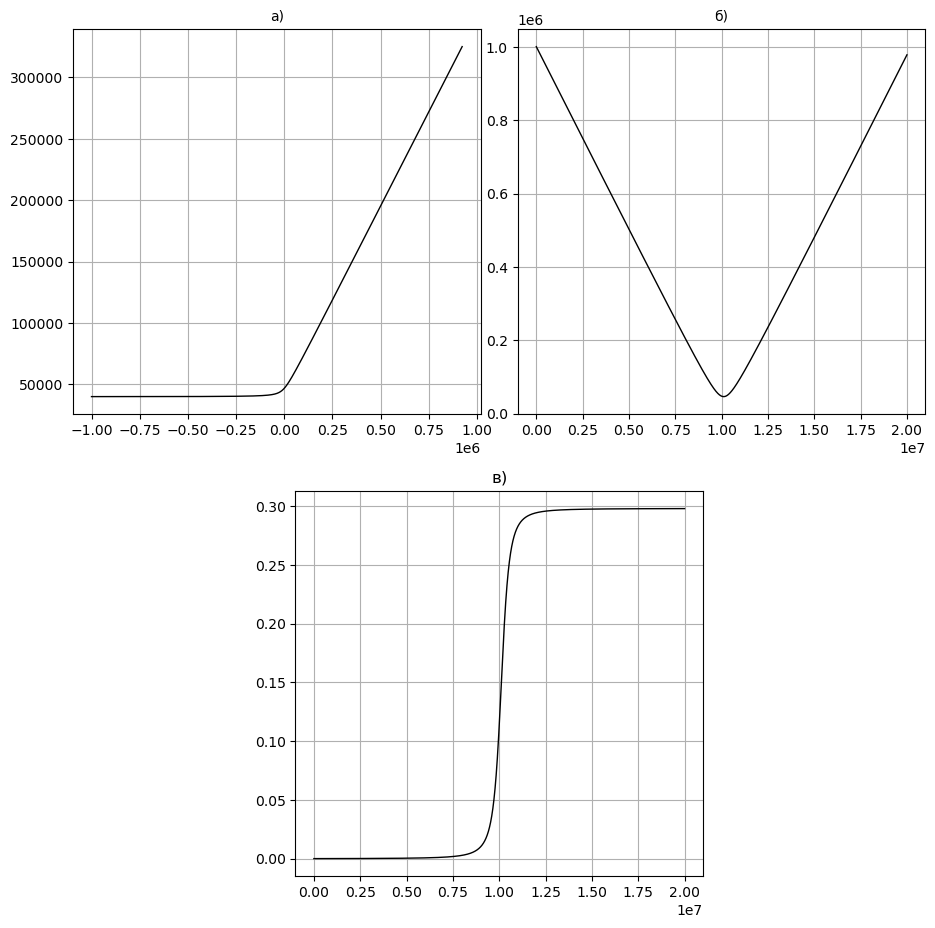

In [4]:
# Ячейка № 4

# визуализация траектории,
# зависимостей модуля радиуса-вектора и
# угла рассеяния рассеиваемой частицы от времени


fig = plt.figure(figsize=(11, 11))
# отображаем в одном графическом окне одновременно:
# траекторию рассеиваемой частицы,
# зависимость модуля радиуса-вектора
# рассеиваемой частицы от времени,
# зависимости угла рассеяния от времени
# в одном графическом окне
ax = [None for _ in range(3)]
ax[0] = plt.subplot2grid(
    (2, 4),  # задание размера сетки
    # 2 ряда по 4 элемента
    (0, 0),  # задание  положения
    # первого элемента
    colspan=2,
)  # задание числа колонок
# используемых для отображения графика
# аналогично задаем параметры остальных графиков
ax[1] = plt.subplot2grid((2, 4), (0, 2), colspan=2)
ax[2] = plt.subplot2grid((2, 4), (1, 1), colspan=2)
# визуализация траектории рассеиваемой частицы
ax[0].set_title(r"а)", fontsize=10)
ax[0].plot(x, y, "-k", lw=1)
ax[0].grid(True)

# визуализация зависимости
# модуля радиуса-вектора рассеиваемой частицы от времени
ax[1].set_title(r"б)", fontsize=10)
ax[1].plot(t, R, "-k", lw=1)
ax[1].grid(True)

# визуализация зависимости
# угла рассеяния от времени
ax[2].set_title(r"в)")
ax[2].plot(t, Chi, "-k", lw=1)
ax[2].grid(True)

plt.show()